In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from matplotlib import pyplot as plt
import seaborn as sns
import arviz
import warnings

warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

sns.set_style("ticks",{'axes.grid' : True})
sns.set_theme(rc={'figure.figsize':(8, 8)})

Mounted at /content/drive


## Задание 1, вариант 2

1. Постройте линейную модель, где в качестве независимых переменных выступают высота, ширина экрана (атрибуты sc_h и sc_w) и емкость аккумулятора (вместе сосвободным коэффициентом), зависимой – масса телефона.
2. Проверьте следующие подозрения:
- Чем больше высота экрана, тем больше масса
- Чем больше ширина экрана, тем больше масса
Проверьте гипотезу $H_0$ о равенстве одновременно нулю коэффициентов при ширине
экрана и емкости аккумулятора против альтернативы $H_a$ = $\overline{H_0}$

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/files/mobile_phones.csv")
n = len(df)
df.sample(5)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
1898,684,1,0.9,1,3,1,63,1.0,157,5,...,159,1738,3756,17,5,12,1,1,1,3
1318,1275,1,0.5,1,3,1,5,0.2,152,1,...,19,501,3784,13,4,4,1,1,0,3
1857,914,1,0.7,0,1,1,60,0.9,198,5,...,740,840,3736,14,8,5,1,0,0,3
410,1029,1,1.9,1,5,1,5,0.2,171,5,...,264,956,582,15,7,4,1,1,1,0
1855,856,1,1.1,1,14,1,19,0.7,125,6,...,1057,1931,650,17,0,10,1,0,1,0


In [ ]:
X = np.column_stack([np.ones(n), df[["sc_h", "sc_w", "battery_power"]].values])
p = X.shape[1]
Y = df["mobile_wt"].to_numpy().reshape(-1, 1)

In [ ]:
theta_hat = (np.linalg.inv(X.T @ X) @ X.T @ Y).reshape(-1, 1)
theta_hat

array([[ 1.43640572e+02],
       [-2.63548169e-01],
       [-3.95486159e-02],
       [ 6.44803879e-05]])

In [ ]:
Y_hat = X @ theta_hat
Y_hat

array([[141.04609091],
       [139.10744201],
       [140.69874762],
       ...,
       [141.35231214],
       [138.5987134 ],
       [138.50784758]])

In [ ]:
sigma2_hat = ((Y - Y_hat) ** 2).sum() / (n - p)
theta_SE = np.sqrt(np.diag(sigma2_hat * np.linalg.inv(X.T @ X))).reshape(-1, 1)

In [ ]:
alpha = 0.05
t_crit = stats.t.ppf(1 - alpha / 2, df=n - p)
conf_intervals = np.hstack([
    theta_hat - t_crit * theta_SE,
    theta_hat + t_crit * theta_SE
])

In [ ]:
feature_names = ['Intercept', 'sc_h', 'sc_w', 'battery_power']
print("Доверительные интервалы")
for i in range(p):
    print(f"{feature_names[i]}: {theta_hat[i,0]:.4f} "
          f"[{conf_intervals[i,0]:.4f} ; {conf_intervals[i,1]:.4f}]")

Доверительные интервалы
Intercept: 143.6406 [137.0500 ; 150.2311]
sc_h: -0.2635 [-0.6910 ; 0.1639]
sc_w: -0.0395 [-0.4529 ; 0.3738]
battery_power: 0.0001 [-0.0035 ; 0.0036]


In [ ]:
R2 = 1 - ((Y - Y_hat) ** 2).sum() / (np.sum((Y - Y.mean()) ** 2))
print(f"Коэффициент детерминации R2 равен {R2.item():.4f}")

Коэффициент детерминации R2 равен 0.0012


Чем больше высота экрана, тем больше масса

$H_0$: $\theta_1=0$

$H_a$: $\theta_1 > 0$

In [ ]:
t_sc_h = theta_hat[1][0] / theta_SE[1][0]
if t_sc_h > t_crit:
  print(f"Гипотеза отвергается, так как ${t_sc_h=:.4f} > {t_crit=:.4f}$")
else:
  print(f"Гипотеза принимается, так как ${t_sc_h=:.4f} <= {t_crit=:.4f}$")

Гипотеза принимается, так как $t_sc_h=-1.2090 <= t_crit=1.9612$


Чем больше ширина экрана, тем больше масса

$H_0$: $\theta_2=0$

$H_a$: $\theta_2 > 0$

In [ ]:
t_sc_w = theta_hat[2][0] / theta_SE[2][0]
if t_sc_w > t_crit:
  print(f"Гипотеза отвергается, так как ${t_sc_w=:.4f} > {t_crit=:.4f}$")
else:
  print(f"Гипотеза принимается, так как ${t_sc_w=:.4f} <= {t_crit=:.4f}$")

Гипотеза принимается, так как $t_sc_w=-0.1876 <= t_crit=1.9612$


Проверьте гипотезу $H_0$ о равенстве одновременно нулю коэффициентов при ширине
экрана и емкости аккумулятора против альтернативы $H_a = \overline{H_0}$

$H_0$: $\theta_2 = \theta_3 = 0$

$H_a$: $\theta_2 \ne 0$ или $\theta_3 \ne 0$

In [ ]:
# Ограниченная модель (только sc_h)
X_sc_h = np.column_stack([np.ones(n), df[['sc_h']]])
theta_sc_h = np.linalg.inv(X_sc_h.T @ X_sc_h) @ X_sc_h.T @ Y
Y_hat_sc_h = X_sc_h @ theta_sc_h
R2_sc_h = 1 - ((Y - Y_hat_sc_h)**2).sum() / ((Y - Y.mean())**2).sum()

In [ ]:
# F-статистика
q = 2
F_obs = ((R2 - R2_sc_h) / q) / ((1 - R2) / (n - p))
F_crit = stats.f.ppf(1 - alpha, dfn=q, dfd=n - p)

In [ ]:
if F_obs > F_crit:
  print(f"Гипотеза отвергается, так как ${F_obs=:.4f} > {F_crit=:.4f}$")
else:
  print(f"Гипотеза принимается, так как ${F_obs=:.4f} <= {F_crit=:.4f}$")

Гипотеза принимается, так как $F_obs=0.0183 <= F_crit=3.0002$


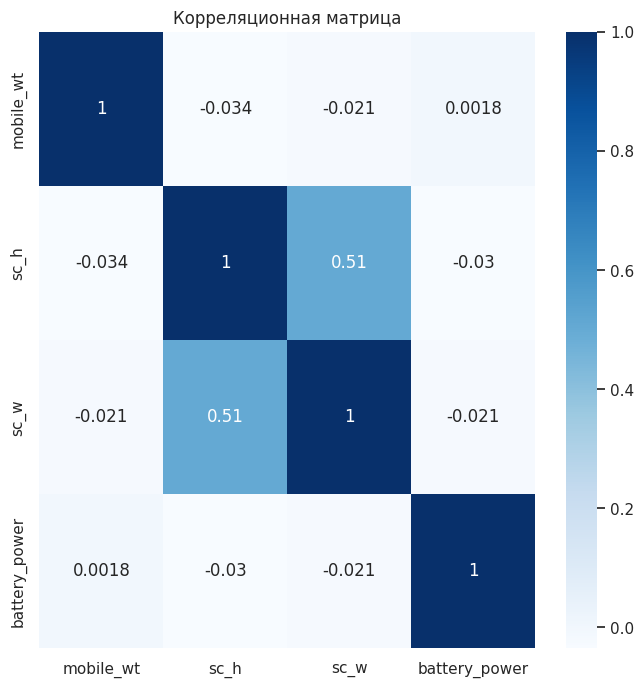

In [ ]:
sns.heatmap(df[["mobile_wt", "sc_h", "sc_w", "battery_power"]].corr(), annot=True, cmap="Blues")
plt.title("Корреляционная матрица")
plt.show()


## Задание 2, вариант 2

Требуется проверить гипотезу о равенстве средних на каждом уровне фактора с помощью модели однофакторного дисперсионного анализа В файле представлены данные о сдаче экзаменов. Фактор – этническая/национальная группа. Выходная переменная – суммарный балл за все три экзамена.

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/files/exams_dataset.csv")
df["total_score"] = df[["math score", "reading score", "writing score"]].sum(axis=1)
n = len(df)
groups = df.groupby("race/ethnicity")["total_score"].apply(list)

df.sample(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score
927,male,group B,some college,standard,none,51,44,49,144
756,male,group C,some high school,standard,none,56,49,48,153
58,male,group C,high school,free/reduced,completed,84,79,81,244
561,female,group D,some high school,free/reduced,none,30,45,39,114
960,female,group C,high school,standard,completed,71,83,89,243


In [ ]:
n_total = len(df)
grand_mean = df["total_score"].mean()

# between groups
SSB = sum(len(group) * (np.mean(group) - grand_mean)**2 for group in groups)
# within groups
SSW = sum(sum((x - np.mean(group))**2 for x in group) for group in groups)

k = len(groups)
df_between = k - 1
df_within = n_total - k

MSB = SSB / df_between
MSW = SSW / df_within

F = MSB / MSW
F_crit = stats.f.ppf(1 - alpha, df_between, df_within)

In [ ]:
if F > F_crit:
  print(f"Гипотеза отвергается, так как ${F=:.4f} > {F_crit=:.4f}$")
else:
  print(f"Гипотеза принимается, так как ${F=:.4f} <= {F_crit=:.4f}$")

Гипотеза отвергается, так как $F=14.3108 > F_crit=2.3809$


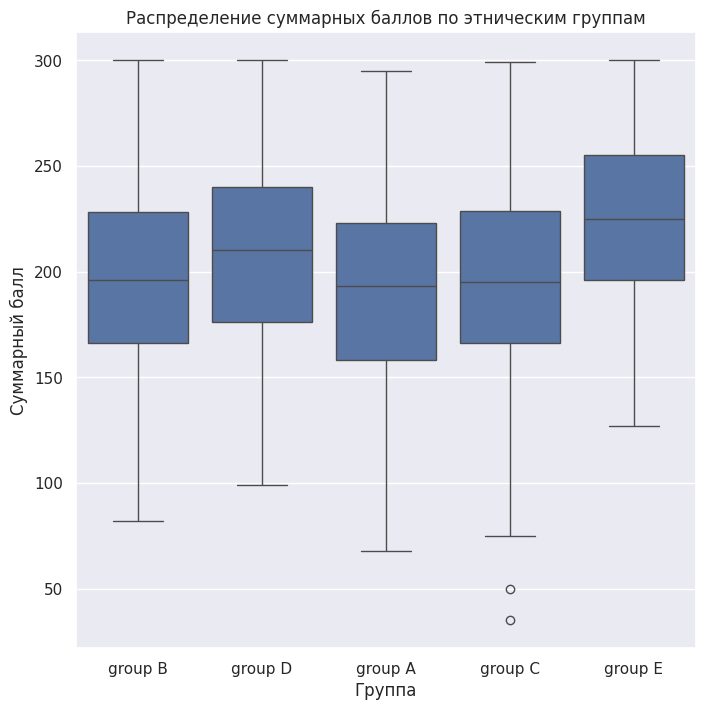

In [ ]:
sns.boxplot(x="race/ethnicity", y="total_score", data=df)
plt.title("Распределение суммарных баллов по этническим группам")
plt.xlabel("Группа")
plt.ylabel("Суммарный балл")
plt.show()


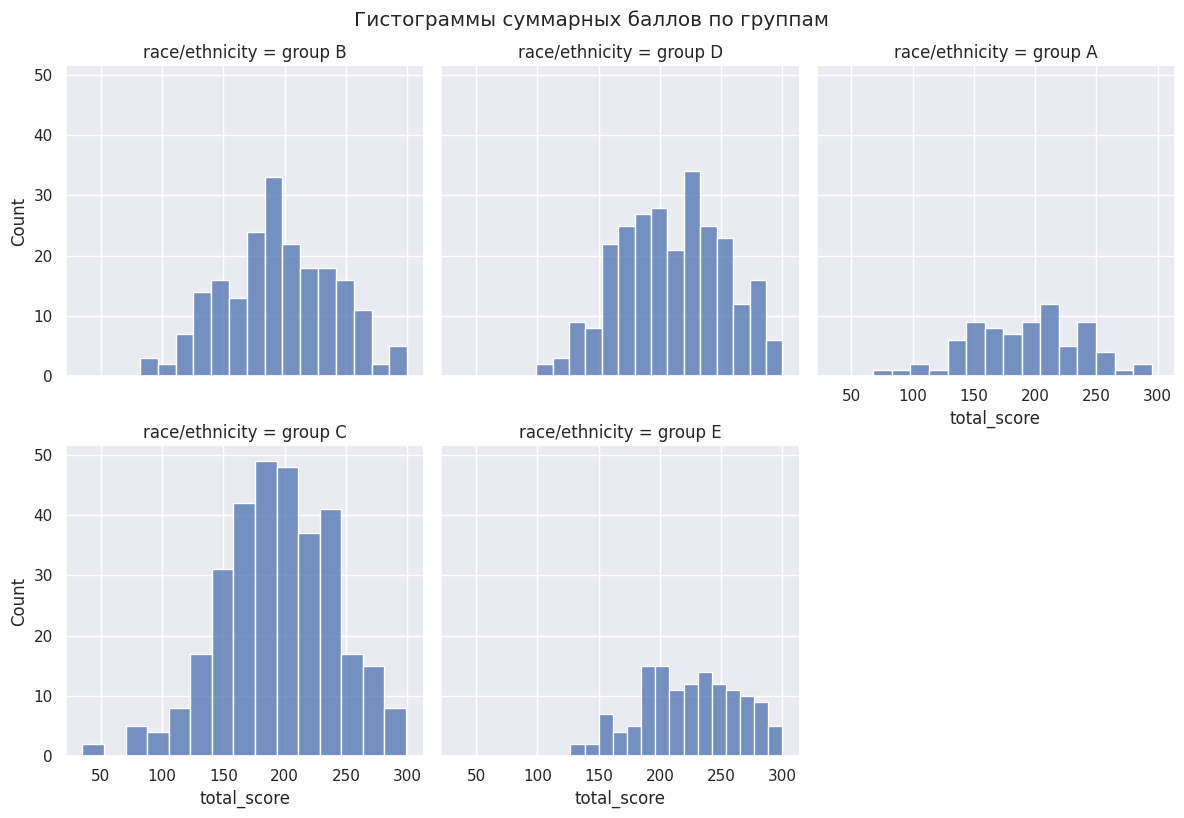

In [ ]:
g = sns.FacetGrid(df, col="race/ethnicity", col_wrap=3, height=4)
g.map(sns.histplot, "total_score", bins=15)
g.fig.suptitle("Гистограммы суммарных баллов по группам", y=1.02)
plt.show()